In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/ipl.csv')
df

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,Lucknow Super Giants,Royal Challengers Bengaluru,2025-05-27,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,JM Sharma,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"Akash Singh, MR Marsh, MP Breetzke, RR Pant, N...","Suyash Sharma, PD Salt, V Kohli, RM Patidar, L...",18,70,League,wickets,6.0,228.0,20.0,N
1165,Punjab Kings,Royal Challengers Bengaluru,2025-05-29,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,Suyash Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,"Priyansh Arya, P Simran Singh, JP Inglis, SS I...","Suyash Sharma, PD Salt, V Kohli, MA Agarwal, R...",18,71,Qualifier 1,wickets,8.0,102.0,20.0,N
1166,Mumbai Indians,Gujarat Titans,2025-05-30,Mumbai Indians,bat,Mumbai Indians,RG Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,"Ashwani Kumar, RG Sharma, JM Bairstow, SA Yada...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,...",18,72,Eliminator,runs,20.0,229.0,20.0,N
1167,Mumbai Indians,Punjab Kings,2025-06-01,Punjab Kings,field,Punjab Kings,SS Iyer,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"Ashwani Kumar, RG Sharma, JM Bairstow, Tilak V...","YS Chahal, Priyansh Arya, P Simran Singh, JP I...",18,73,Qualifier 2,wickets,5.0,204.0,20.0,N


In [ ]:
# Number of columns and rows
print(f"The DataFrame is having {df.shape[0]} rows and {df.shape[1]} columns ")

The DataFrame is having 1169 rows and 19 columns 


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team1            1169 non-null   object 
 1   team2            1169 non-null   object 
 2   match_date       1169 non-null   object 
 3   toss_winner      1169 non-null   object 
 4   toss_decision    1169 non-null   object 
 5   winner           1146 non-null   object 
 6   player_of_match  1169 non-null   object 
 7   venue            1169 non-null   object 
 8   city             1118 non-null   object 
 9   team1_players    1169 non-null   object 
 10  team2_players    1169 non-null   object 
 11  season           1169 non-null   int64  
 12  match_number     1169 non-null   int64  
 13  match_type       1169 non-null   object 
 14  result           1169 non-null   object 
 15  result_margin    1146 non-null   float64
 16  target_runs      1163 non-null   float64
 17  target_overs  

In [ ]:
# Fixing all datatypes

# 1. Convert date
df['match_date'] = pd.to_datetime(df['match_date'], errors='coerce')

# 2. Convert player columns (string → list)
df['team1_players'] = df['team1_players'].apply(lambda x: [p.strip() for p in x.split(',')])
df['team2_players'] = df['team2_players'].apply(lambda x: [p.strip() for p in x.split(',')])

# 3. Convert super_over Y/N → 1/0
df['super_over'] = df['super_over'].map({'Y': 1, 'N': 0})

# 4. Convert numeric columns
num_cols = ['result_margin', 'target_runs', 'target_overs']
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')

# 5. Convert some object columns to category
category_cols = [
    'team1', 'team2', 'toss_winner', 'toss_decision',
    'winner', 'player_of_match', 'venue', 'city',
    'match_type', 'result'
]
for col in category_cols:
    df[col] = df[col].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   team1            1169 non-null   category      
 1   team2            1169 non-null   category      
 2   match_date       1169 non-null   datetime64[ns]
 3   toss_winner      1169 non-null   category      
 4   toss_decision    1169 non-null   category      
 5   winner           1146 non-null   category      
 6   player_of_match  1169 non-null   category      
 7   venue            1169 non-null   category      
 8   city             1118 non-null   category      
 9   team1_players    1169 non-null   object        
 10  team2_players    1169 non-null   object        
 11  season           1169 non-null   int64         
 12  match_number     1169 non-null   int64         
 13  match_type       1169 non-null   category      
 14  result           1169 non-null   categor

In [ ]:
df.shape

(1169, 19)

In [ ]:
df.isnull().sum()

,0
team1,0
team2,0
match_date,0
toss_winner,0
toss_decision,0
winner,23
player_of_match,0
venue,0
city,51
team1_players,0


In [ ]:
# Fixing Missing values

# 1. Winner missing values
df['winner'] = df['winner'].cat.add_categories(['No Result'])
df['winner'] = df['winner'].fillna('No Result')

# 2. City missing values
df['city'] = df['city'].cat.add_categories(['Unknown'])
df['city'] = df['city'].fillna('Unknown')

# 3. result_margin missing
df.loc[df['winner'] == "No Result", 'result_margin'] = 0
df['result_margin'] = df['result_margin'].fillna(0)

# 4. target_runs & target_overs missing
df['target_runs'] = df['target_runs'].fillna(0)
df['target_overs'] = df['target_overs'].fillna(0)

In [ ]:
df.isna().sum()

,0
team1,0
team2,0
match_date,0
toss_winner,0
toss_decision,0
winner,0
player_of_match,0
venue,0
city,0
team1_players,0


In [ ]:
# Check unique values of all categorical columns

for col in df.select_dtypes(['category']).columns:
    print(col, "→", df[col].nunique())
    print(df[col].unique()[:20])
    print("-"*50)

team1 → 19
['Royal Challengers Bangalore', 'Kings XI Punjab', 'Delhi Daredevils', 'Mumbai Indians', 'Kolkata Knight Riders', ..., 'Delhi Capitals', 'Punjab Kings', 'Lucknow Super Giants', 'Gujarat Titans', 'Royal Challengers Bengaluru']
Length: 19
Categories (19, object): ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils',
                          ..., 'Rising Pune Supergiants',
                          'Royal Challengers Bangalore', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']
--------------------------------------------------
team2 → 19
['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals', 'Royal Challengers Bangalore', 'Deccan Chargers', ..., 'Delhi Capitals', 'Punjab Kings', 'Gujarat Titans', 'Lucknow Super Giants', 'Royal Challengers Bengaluru']
Length: 19
Categories (19, object): ['Chennai Super Kings', 'Deccan Chargers', 'Delhi Capitals', 'Delhi Daredevils',
                          ..., 'Rising Pune Supergiants',
         

In [ ]:
# Number of Teams
df['team1'].nunique()

19

In [ ]:
df['team2'].nunique()

19

In [ ]:
sorted(list(df['team1'].unique()))

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiant',
 'Rising Pune Supergiants',
 'Royal Challengers Bangalore',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [ ]:
# Number of venues and their names

df['venue'].nunique()
df['venue'].unique()

['M Chinnaswamy Stadium', 'Punjab Cricket Association Stadium, Mohali', 'Feroz Shah Kotla', 'Wankhede Stadium', 'Eden Gardens', ..., 'Sawai Mansingh Stadium, Jaipur', 'Himachal Pradesh Cricket Association Stadium,..., 'Maharaja Yadavindra Singh International Crick..., 'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket S..., 'Maharaja Yadavindra Singh International Crick...]
Length: 59
Categories (59, object): ['Arun Jaitley Stadium', 'Arun Jaitley Stadium, Delhi', 'Barabati Stadium',
                          'Barsapara Cricket Stadium, Guwahati', ..., 'Vidarbha Cricket Association Stadium, Jamtha',
                          'Wankhede Stadium', 'Wankhede Stadium, Mumbai',
                          'Zayed Cricket Stadium, Abu Dhabi']

In [ ]:
# Basic match statistics (Total number of matches per season)

matches_season = df.groupby('season').size()
matches_season

,0
season,
1,58
2,57
3,60
4,73
5,74
6,76
7,60
8,59
9,60


In [ ]:
# Average result margin
df['result_margin'].mean()

np.float64(17.00940975192472)

In [ ]:
# Average margin by winner

df.groupby('winner')['result_margin'].mean().sort_values(ascending=False)

/tmp/ipykernel_19281/3243141104.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('winner')['result_margin'].mean().sort_values(ascending=False)


,result_margin
winner,
Rising Pune Supergiant,27.600000
Chennai Super Kings,24.253521
Gujarat Titans,19.378378
Royal Challengers Bengaluru,18.722222
Mumbai Indians,17.860927
Pune Warriors,17.666667
Royal Challengers Bangalore,17.438596
Kolkata Knight Riders,17.362963
Kings XI Punjab,17.176471


In [ ]:
# Top 3 teams with highest average win margin

df.groupby('winner')['result_margin'].mean().sort_values(ascending=False).head(3)

/tmp/ipykernel_19281/531827301.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('winner')['result_margin'].mean().sort_values(ascending=False).head(3)


,result_margin
winner,
Rising Pune Supergiant,27.600000
Chennai Super Kings,24.253521
Gujarat Titans,19.378378


In [ ]:
# Toss decision statistics

df['toss_decision'].value_counts()

,count
toss_decision,
field,764
bat,405


In [ ]:
# Player of the match — top players

df['player_of_match'].value_counts().head(10)

,count
player_of_match,
AB de Villiers,25
CH Gayle,22
RG Sharma,21
V Kohli,19
MS Dhoni,18
DA Warner,18
SP Narine,17
YK Pathan,16
AD Russell,16


In [ ]:
# Number of matches each team played

(df['team1'].value_counts() + df['team2'].value_counts()).sort_values(ascending=False)

,count
Mumbai Indians,277
Kolkata Knight Riders,264
Chennai Super Kings,252
Royal Challengers Bangalore,240
Rajasthan Royals,235
Sunrisers Hyderabad,196
Kings XI Punjab,190
Delhi Daredevils,161
Delhi Capitals,106
Deccan Chargers,75


Visualizations

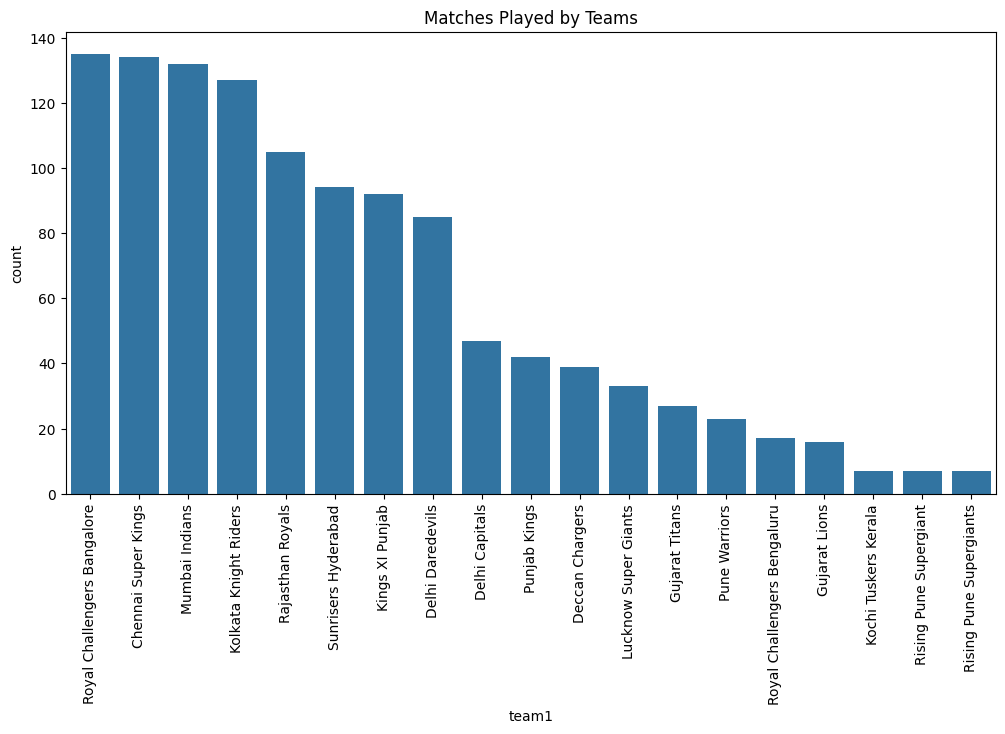

In [ ]:
# 1. Countplot – Most Matches Played by Teams -> Shows which team appears most across seasons.

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='team1', order=df['team1'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Matches Played by Teams")
plt.show()

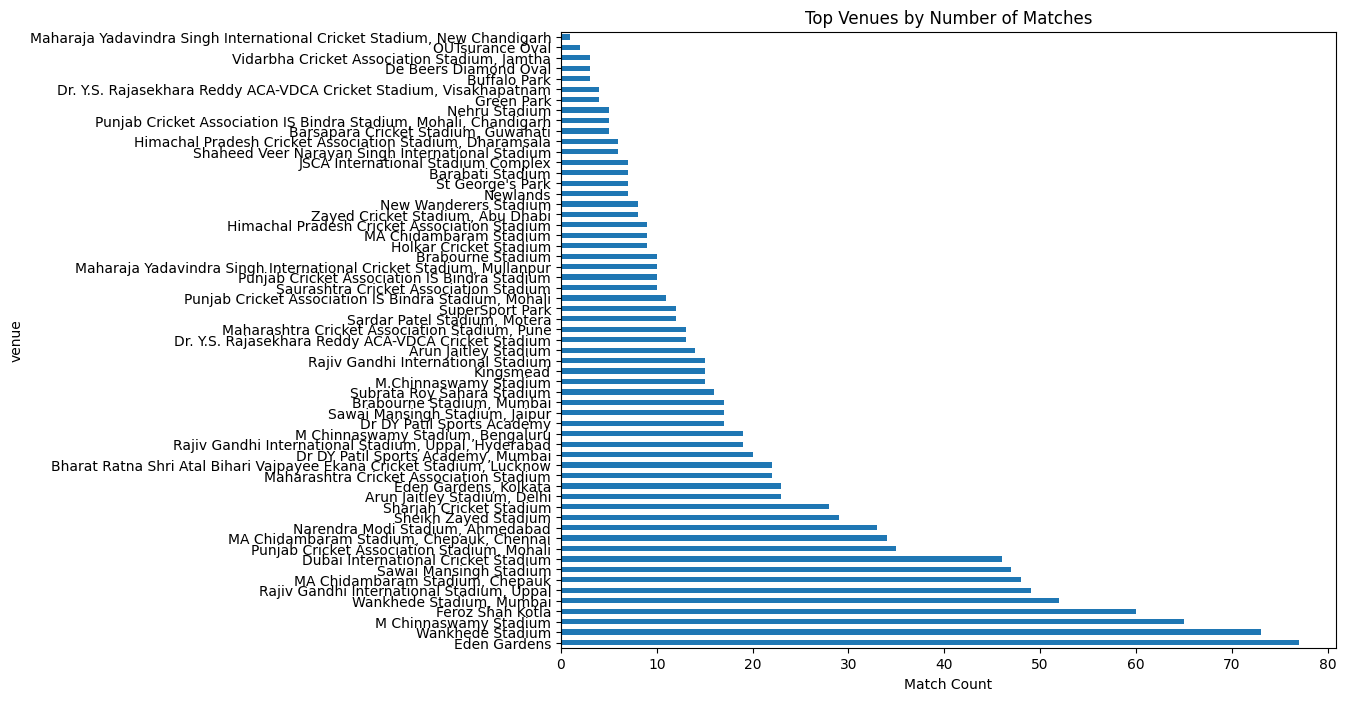

In [ ]:
# Horizontal Bar Plot – Venues With Most Matches

plt.figure(figsize=(10,8))
df['venue'].value_counts().plot(kind='barh')
plt.title("Top Venues by Number of Matches")
plt.xlabel("Match Count")
plt.show()

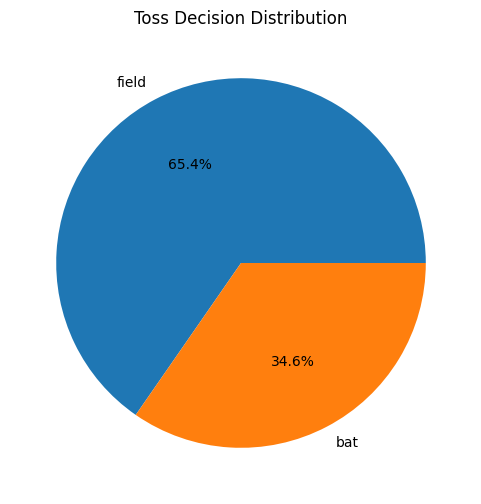

In [ ]:
# Pie Chart – Toss Decisions (Bat or Field)

df['toss_decision'].value_counts().plot(kind='pie', autopct='%1.1f%%',
                                        figsize=(6,6), ylabel='')
plt.title("Toss Decision Distribution")
plt.show()

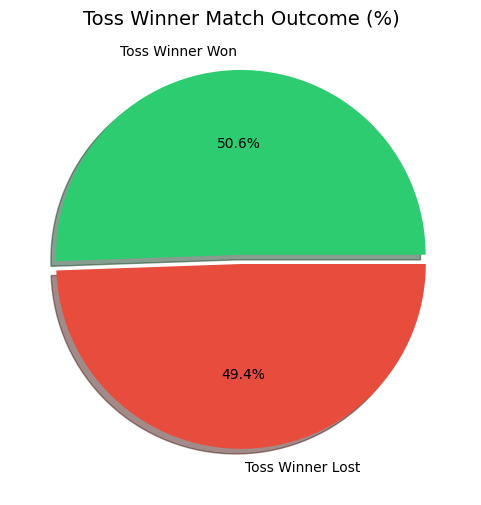

In [ ]:
# 3 – % of Toss-Winner Winning Match (Pie Chart)

value = (df['toss_winner'].astype(str) == df['winner'].astype(str)).mean() * 100

plt.figure(figsize=(6,6))
plt.pie(
    [value, 100-value],
    labels=['Toss Winner Won', 'Toss Winner Lost'],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    explode=[0.05, 0],
    shadow=True
)
plt.title("Toss Winner Match Outcome (%)", fontsize=14)
plt.show()


/tmp/ipykernel_19281/1102562765.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='toss_match_win', palette='Set2')


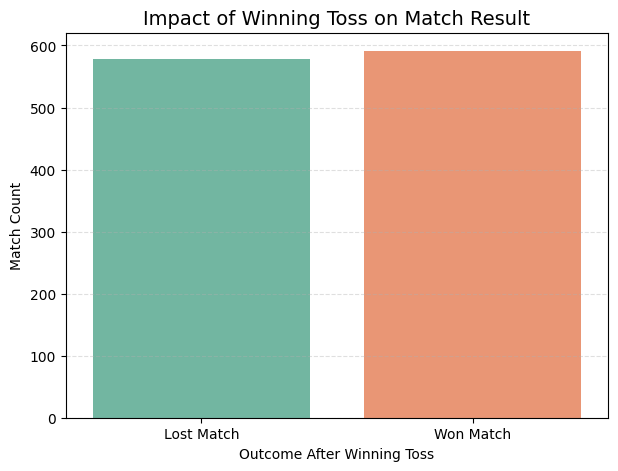

In [ ]:
# 4 – Toss Winner vs Match Winner
df['toss_match_win'] = np.where(
    df['toss_winner'].astype(str) == df['winner'].astype(str),
    'Won Match',
    'Lost Match'
)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='toss_match_win', palette='Set2')
plt.title("Impact of Winning Toss on Match Result", fontsize=14)
plt.ylabel("Match Count")
plt.xlabel("Outcome After Winning Toss")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

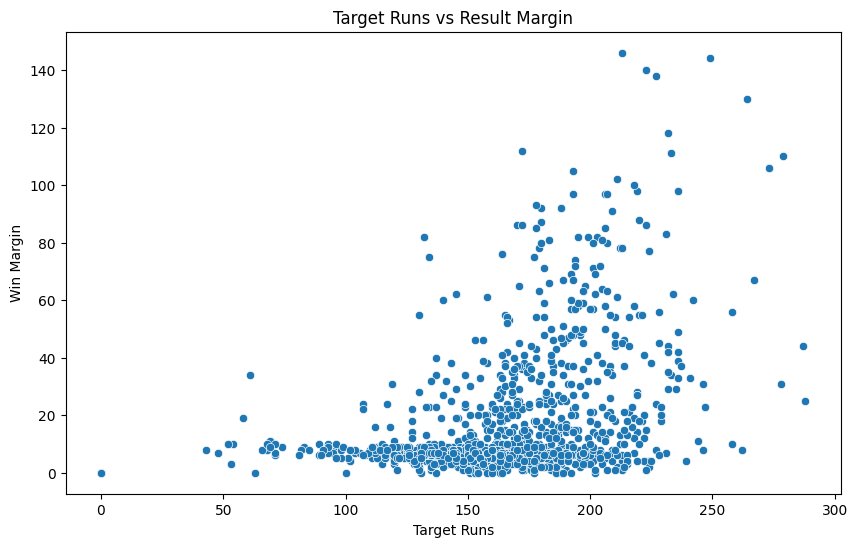

In [ ]:
# Scatter Plot – Target Runs vs Result Margin (Shows if high targets lead to big wins.)

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='target_runs', y='result_margin')
plt.title("Target Runs vs Result Margin")
plt.xlabel("Target Runs")
plt.ylabel("Win Margin")
plt.show()

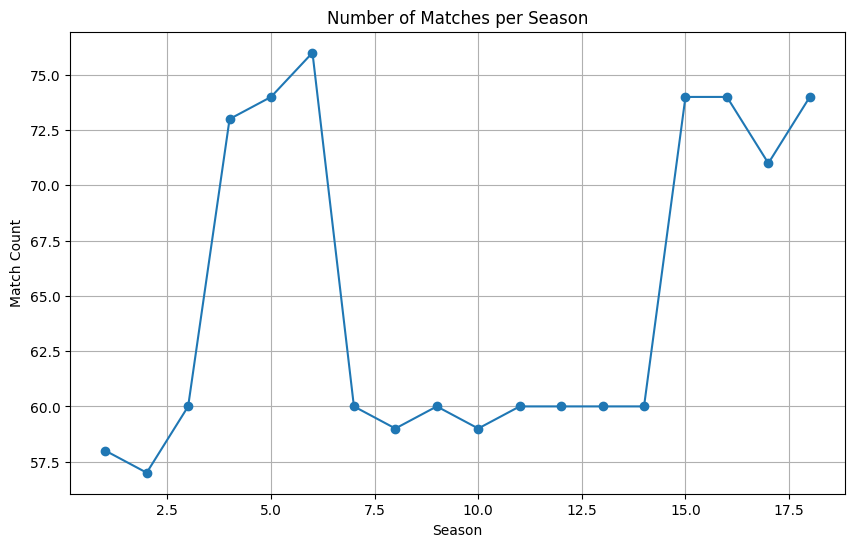

In [ ]:
# Line Plot – Matches Played per Season (Shows growth trend of IPL.)

season_counts = df['season'].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.plot(season_counts.index, season_counts.values, marker='o')
plt.title("Number of Matches per Season")
plt.xlabel("Season")
plt.ylabel("Match Count")
plt.grid()
plt.show()

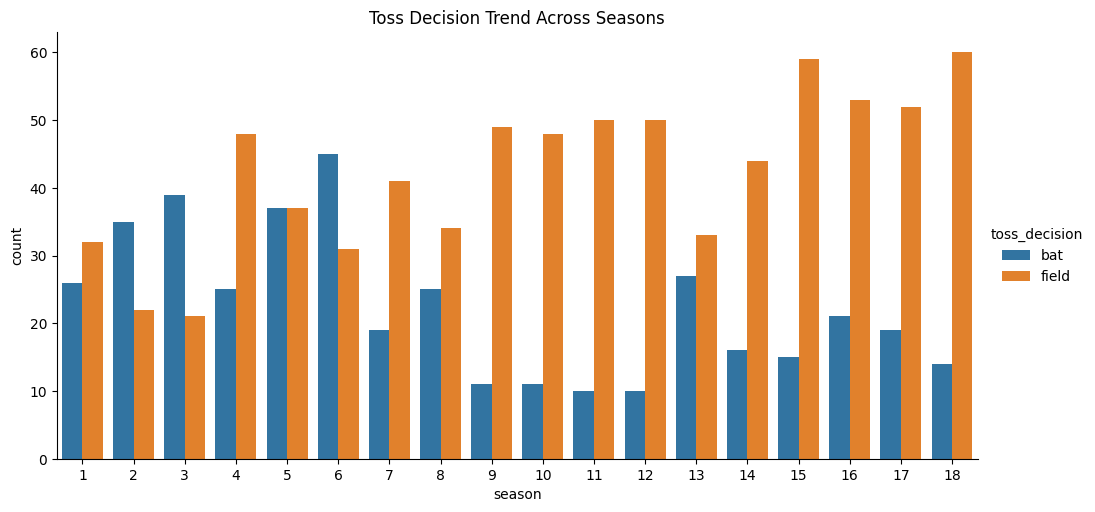

In [ ]:
# Catplot – Toss Decision Over Seasons (Shows how strategies changed over time.)

sns.catplot(data=df, x='season', hue='toss_decision', kind='count',
            height=5, aspect=2)
plt.title("Toss Decision Trend Across Seasons")
plt.show()

/tmp/ipykernel_19281/3246615242.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=wrapped_labels, x=top_pom.values, palette="viridis")


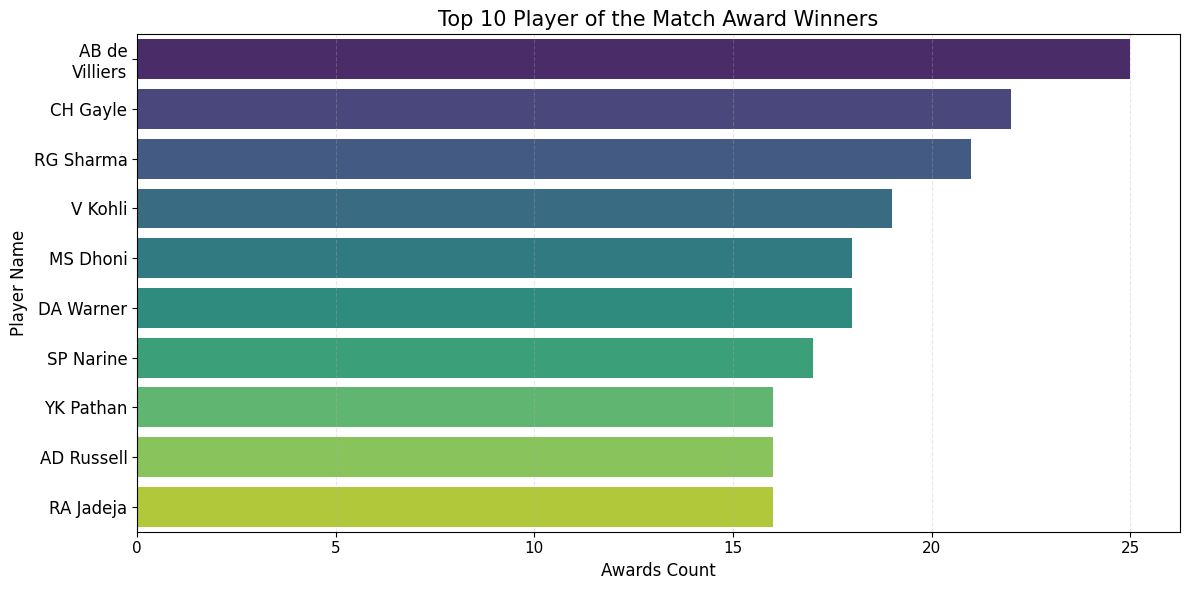

In [ ]:
# Countplot – Most Player of the Match Awards (Top performers)

import textwrap

top_pom = df['player_of_match'].value_counts().head(10)

wrapped_labels = [textwrap.fill(label, 12) for label in top_pom.index]

plt.figure(figsize=(12,6))
sns.barplot(y=wrapped_labels, x=top_pom.values, palette="viridis")

plt.title("Top 10 Player of the Match Award Winners", fontsize=15)
plt.xlabel("Awards Count", fontsize=12)
plt.ylabel("Player Name", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.xticks(fontsize=11)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

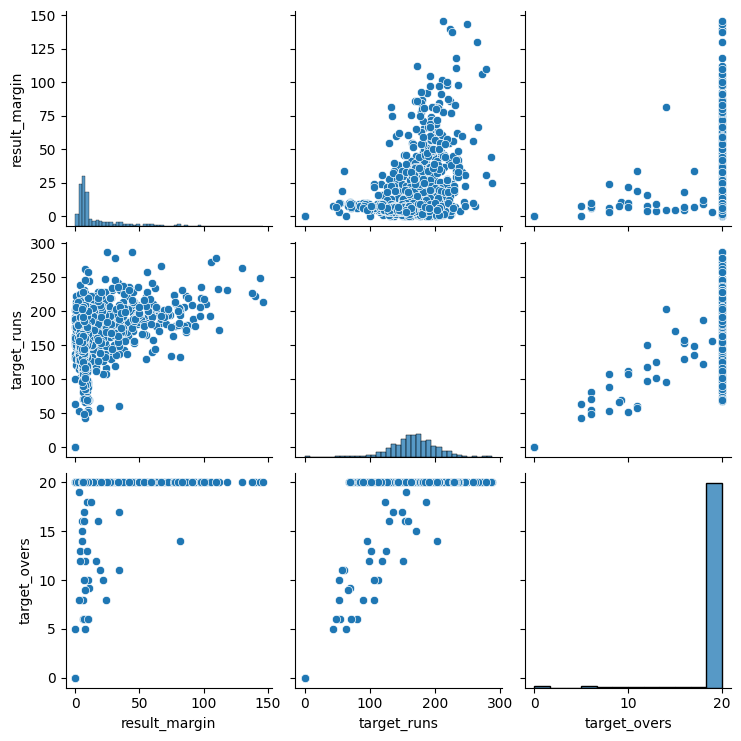

In [ ]:
# Pair Plot – Relationship Between Numerical Match Stats (Gives deep insights into correlations)

sns.pairplot(df[['result_margin','target_runs','target_overs']])
plt.show()

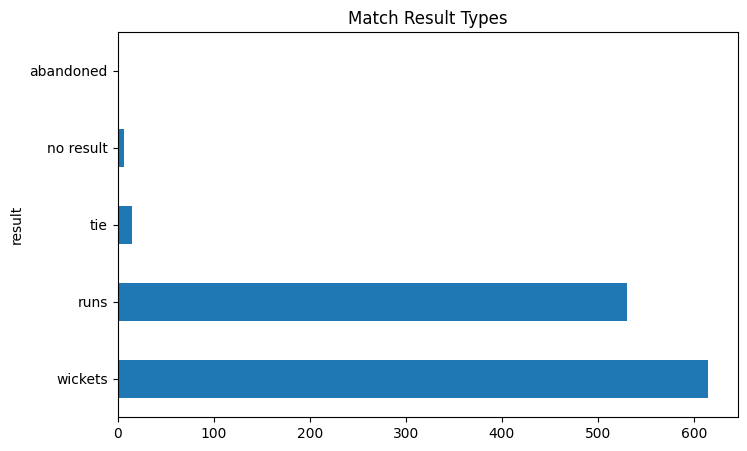

In [ ]:
# Win % by Batting First vs Chasing (Horizontal bar)

plt.figure(figsize=(8,5))
df['result'].value_counts().plot(kind='barh')
plt.title("Match Result Types")
plt.show()

# Final Conclusion
From the IPL data analysis, we found that:

- Toss does not decide the winner — teams win the match almost equally whether
they win the toss or not.
- Some venues are more high-scoring, and home teams get a slight advantage on their home grounds.
- Teams like MI, CSK, and KKR are the most consistent and win the most matches.
- Star players (like Kohli, Dhoni, Gayle, etc.) win the most “Player of the Match” awards, showing that individual performance strongly affects match results.
- Over the years, scores have increased, and matches have become more competitive.
- Most matches have a clear winner; very few end in “No Result”.

**Overall**

IPL match outcomes depend mainly on team performance, player impact, and venue conditions — not the toss. Teams with strong batting & bowling balance win more consistently.